# Ham and Spam email classification
## 1. EDA
- First we perform EDA with the input data
- Following actions are performed:
    - Check for missing values
    - Distribution of target labels
    - Histogram of wordcounts
    - Most common words
    - Domain analysis

In [1]:
import numpy as np
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc,confusion_matrix,classification_report


In [2]:
df = pd.read_csv("emails.csv")

### 1.1. Dataset overview

In [3]:

df.head()

,Unnamed: 0,filename,contents,target
0,0,00249.5f45607c1bffe89f60ba1ec9f878039a,"Dear Homeowner,\n \nInterest Rates are at thei...",1
1,1,0355.94ebf637e4bd3db8a81c8ce68ecf681d,"Friend,Now you can copy DVD's and Games\nhttp:...",1
2,2,0395.bb934e8b4c39d5eab38f828a26f760b4,Pocket the newest 8 year annuity!\t Pocket th...,1
3,3,0485.9021367278833179285091e5201f5854,Congratulations! You Get a Free Handheld Organ...,1
4,4,00373.ebe8670ac56b04125c25100a36ab0510,ATTENTION: This is a MUST for ALL Computer Use...,1


In [4]:
print(f"Dataset dimensions: {df.shape[0]} emails, {df.shape[1]} features")

Dataset dimensions: 9353 emails, 4 features


- There are 9353 emails
- Althought there are 4 features, the input is the email content which is the **contents** columns and the output is the **target** columns
- The target column contains only binary value to indicate if the email is:
    - **0: Ham**
    - **1: Spam** 

### 1.2. Missing values

In [5]:
missing_values = np.array([not isinstance(text, str) for text in df['contents'].values])
missing_count = np.sum(missing_values)
print(f"Missing values in content: {missing_count} ({missing_count/len(df):.2%})")
df[missing_values]

Missing values in content: 146 (1.56%)


,Unnamed: 0,filename,contents,target
13,13,0146.6656452972931e859e640f6ac57d2962,NaN,1
78,78,00139.b2a205ac25d7d907cdfb3f865dbae1ae,NaN,1
169,169,0352.f7adb4aa267e50a8db1e4bcacfe863f3,NaN,1
192,192,00341.99b463b92346291f5848137f4a253966,NaN,1
282,282,0340.8e191c37e2d30a639013203aacf60086,NaN,1
...,...,...,...,...
9057,9057,00565.630d62a91f6d1b297a2069007700e2ae,NaN,0
9126,9126,00653.41f993b29996e0e099849f377ae280e4,NaN,0
9206,9206,01285.d0d97662f93c959244325cc414f96039,NaN,0
9306,9306,01306.642dc8dce3771af294de84e167221354,NaN,0


- There are 146 emails out of 9353 which didnt have any value (NaN), it might be due several reasons:
    - They are blank
    - They contain only images with links to some harmful sources
    - They could not be converted from original email 

- Since the objective of our Case Study is to do the modeling and the number of missing emails are small ~ 1.5%, we temporary ignore them for now

In [6]:
df = df[~missing_values]

In [7]:
df.shape

(9207, 4)

### 1.3. Distribution of target labels
- With the removal of missing values, we have 9207 emails left with 6858 ham and 2349 spam emails:

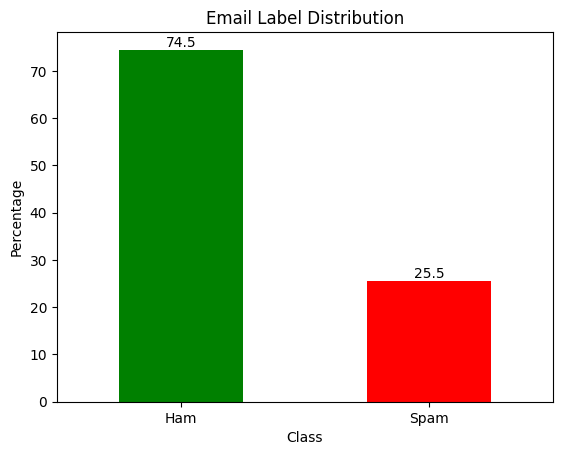

In [8]:
targets = df.target.value_counts(normalize=True)*100
ax = targets.plot(kind='bar', color=['green', 'red'])
custom_labels = ['Ham', 'Spam']
plt.title('Email Label Distribution')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(ticks=range(len(custom_labels)), labels=custom_labels, rotation=0)  
for i, val in enumerate(targets):
    plt.text(i, val + 0.01, f'{val:.1f}', ha='center', va='bottom')

plt.show()


- We can see that 75% are Ham email and about 25% are classified as Spam email
- Next we will see the distribution of number of words

### 1.4. Word counts

In [9]:
df['word_count'] = df['contents'].apply(lambda x: len(str(x).split()))


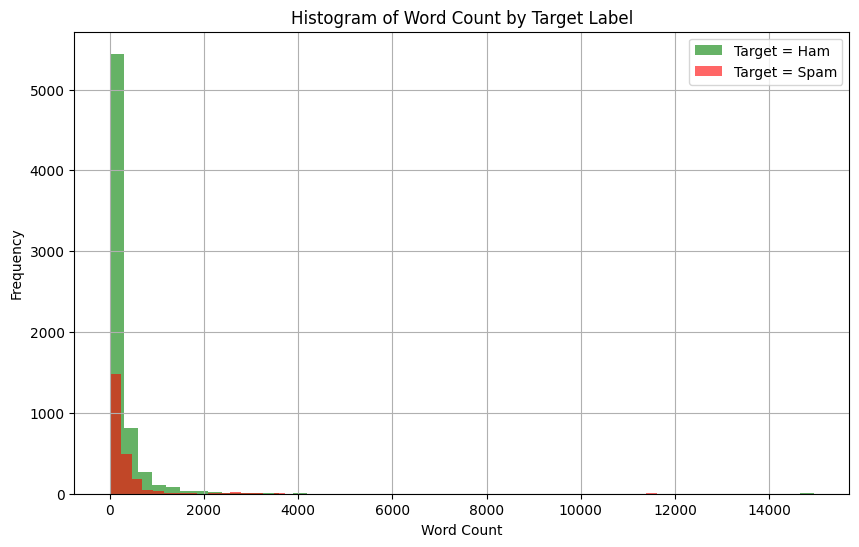

In [10]:
# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(df[df['target'] == 0]['word_count'], bins=50, alpha=0.6, label='Target = Ham',color="green")
plt.hist(df[df['target'] == 1]['word_count'], bins=50, alpha=0.6, label='Target = Spam',color="red")
plt.title('Histogram of Word Count by Target Label')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
df[df['target'] == 0]['word_count'].mean()

274.8662875473899

In [15]:
df[df['target'] == 1]['word_count'].mean()

352.55555555555554

- Both Ham and Spam document have extreme right skew
- More Ham emails than Spam 
- Ham emails tend to be longer than Spam with more values in Word Count
- Most of the documents have less than 2000 words, but there still exits documents with upto 14000 words

Next we will compute the most common words in n-grams:

In [31]:
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Convert to lowercase and remove non-alphanumeric
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    # Remove stopwords
    words = [word for word in text.split() if word not in stop_words and len(word) > 2]
    return ' '.join(words)

# Preprocess text
processed_ham = [preprocess_text(text) for text, label in zip(df['contents'].values, df.target) if label == 0]
processed_spam = [preprocess_text(text) for text, label in zip(df['contents'].values, df.target) if label == 1]

# Extract most common words
vectorizer = CountVectorizer(max_features=20)
ham_counts = vectorizer.fit_transform(processed_ham)
ham_words = vectorizer.get_feature_names_out()
ham_freq = np.asarray(ham_counts.sum(axis=0)).ravel()

vectorizer = CountVectorizer(max_features=20)
spam_counts = vectorizer.fit_transform(processed_spam)
spam_words = vectorizer.get_feature_names_out()
spam_freq = np.asarray(spam_counts.sum(axis=0)).ravel()


In [42]:
top_ham_words = pd.DataFrame({'word': ham_words, 'frequency': ham_freq})
top_ham_words = top_ham_words.sort_values(by='frequency', ascending=True)

top_spam_words = pd.DataFrame({'word': spam_words, 'frequency': spam_freq})
top_spam_words = top_spam_words.sort_values(by='frequency', ascending=True)


In [ ]:

# Plot most common words
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Ham words
ax1.barh(top_ham_words.word, top_ham_words.frequency, color='green')
ax1.set_title('Most Common Words in Ham Emails')
ax1.set_xlabel('Frequency')

# Spam words
ax2.barh(top_spam_words.word, top_spam_words.frequency, color='red')
ax2.set_title('Most Common Words in Spam Emails')
ax2.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

### 1.5 Word Cloud:
- We look at the top buzz words in another angle of Word Cloud
- Notably from the Word Cloud of Spam domain are the words that can form a common sentence: "please click email address website mailing list credit card"

In [ ]:
plt.figure(figsize=(16, 7))

# Ham wordcloud
ham_text = ' '.join(processed_ham)
ham_wordcloud = WordCloud(width=800, height=400, background_color='white', 
                         max_words=100, contour_width=3, contour_color='steelblue')
ham_wordcloud.generate(ham_text)

plt.subplot(1, 2, 1)
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.title('Ham Email Word Cloud')
plt.axis('off')

# Spam wordcloud
spam_text = ' '.join(processed_spam)
spam_wordcloud = WordCloud(width=800, height=400, 
                          max_words=100, contour_width=3, contour_color='blacked')
spam_wordcloud.generate(spam_text)

plt.subplot(1, 2, 2)
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.title('Spam Email Word Cloud')
plt.axis('off')

plt.tight_layout()
plt.show()


### 1.6 Domain analysis
- We will find all email addresses available in the words in Ham and Spam domain context
- Count the frequency and plot the top

In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt

# Compile email regex
email_pattern = re.compile(r'[\w\.-]+@[\w\.-]+')

# Function to extract top domains from a text series
def get_top_domains(text_series, top_n=15):
    domains = []
    for content in text_series:
        if isinstance(content, str):
            emails = email_pattern.findall(content)
            domains.extend([email.split('@')[1] for email in emails if '@' in email])
    return Counter(domains).most_common(top_n)

# Split the DataFrame
ham_df = df[df['target'] == 0]
spam_df = df[df['target'] == 1]

# Get top domains
ham_top_domains = sorted(get_top_domains(ham_df['contents']), key=lambda x: x[1])
spam_top_domains = sorted(get_top_domains(spam_df['contents']), key=lambda x: x[1])

ham_domain_names, ham_domain_counts = zip(*ham_top_domains) if ham_top_domains else ([], [])
spam_domain_names, spam_domain_counts = zip(*spam_top_domains) if spam_top_domains else ([], [])

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

# Ham plot
axes[0].barh(ham_domain_names, ham_domain_counts, color='#2ca02c')
axes[0].set_title('Top Email Domains in Ham')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Domain')

# Spam plot
axes[1].barh(spam_domain_names, spam_domain_counts, color='#d62728')
axes[1].set_title('Top Email Domains in Spam')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()


## 2. Modeling
- Apply Term Frequency - Inverse Document Frequency TFIDF to:
    - Convert words to tokens => tokenizer.
    - Focus on unigram (1 word) and bigrams (2 words)
    - Find the top 5000 most frequent term/tokens and ignore the less frequent items => reduce dimensions

- We build a model to predict if the email is ham or spam:
    - The model in use is Naive Bayes: MultinomialNB from sklearn
    - Apply K-Fold Cross Validation to train the model, find the optimal alpha

### 2.1. Partition the dataset

In [11]:
X = df.contents
y = df.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=123)


### 2.2. Tokenize and apply TFIDF

In [13]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


### 2.3. Build NB model and train with K-Fold CV
- Find optimal alpha values
- Use optimal alpha to train the model

In [14]:
# Find the optimal alpha
param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}
# Use Gridsearch CV to find the best alpha
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train_tfidf, y_train)

# Best alpha
print(f"Best alpha: {grid_search.best_params_['alpha']}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best alpha: 0.001
Best cross-validation score: 0.9817


In [15]:
# Build the model with the best alpha
NB_model = MultinomialNB(alpha=grid_search.best_params_['alpha'])

# Train the model
k_fold = KFold(n_splits=10, shuffle=True, random_state=123)
cv_scores = cross_val_score(NB_model, X_train_tfidf, y_train, cv=k_fold, scoring='accuracy')


In [17]:
print(cv_scores)

[0.97829037 0.99185889 0.97150611 0.98507463 0.97693351 0.98097826
 0.98233696 0.97690217 0.98505435 0.98369565]


### 2.4. Fit the trained model, Predict and calculate the metrics

In [18]:
# Fit the model on the entire training set
NB_model.fit(X_train_tfidf, y_train)


MultinomialNB(alpha=0.001)

In [19]:

# Predict the model
y_pred = NB_model.predict(X_test_tfidf)

# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
test_accuracy

0.9820846905537459

In [25]:
cm = classification_report(y_test, y_pred)


In [26]:
print(cm)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1358
           1       0.97      0.96      0.97       484

    accuracy                           0.98      1842
   macro avg       0.98      0.98      0.98      1842
weighted avg       0.98      0.98      0.98      1842



### 2.5 Plot the ROC 

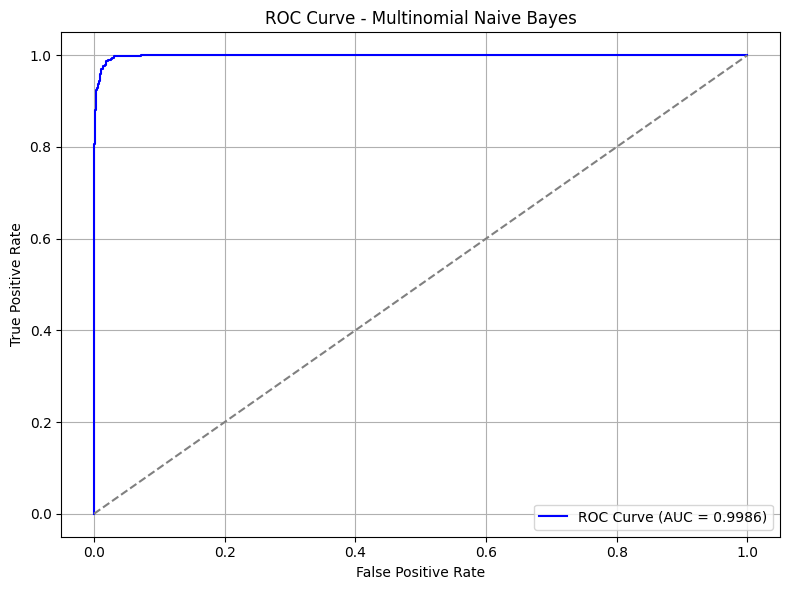

In [27]:
# Step 2: Get predicted probabilities for the positive class (spam = 1)
y_scores = NB_model.predict_proba(X_test_tfidf)[:, 1]

# Step 3: Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Step 4: Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multinomial Naive Bayes')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### 2.6. Different words between Spam and Ham
- Next we calculate the most different probability for the occurence of words in Ham and Spam by using the formulation:
```python
# Calculate log-probability differences: spam - ham
# Assuming class 1 = spam, class 0 = ham
spam_features = log_probs[1] - log_probs[0]
```
- With that said, spam_features is the difference between probability of class 1 (spam) and class 0 (ham)
- If spam_features > 0: the word in unigram/n-gram is more likely to appear in spam than ham
- In the opposite, If spam_features < 0: the word in unigram/n-gram is more likely to appear in ham than spam

In [28]:
# Get feature names from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Get log probabilities for each class
log_probs = NB_model.feature_log_prob_

# Calculate log-probability differences: spam - ham
# Assuming class 1 = spam, class 0 = ham
spam_features = log_probs[1] - log_probs[0]
ham_features = log_probs[0] - log_probs[1]

# Get indices of top 20 spam-indicative features
indices_spam = np.argsort(spam_features)[-20:]
indices_ham = np.argsort(ham_features)[-20:]

# Map indices to feature names and their importance scores
top_spam_features = [(feature_names[i], spam_features[i]) for i in indices_spam]
top_ham_features = [(feature_names[i], ham_features[i]) for i in indices_ham]

In [29]:
indices_ham = np.argsort(spam_features)[:20]
indices_ham

array([3536, 3537, 4891, 2782, 2781, 1655, 3385, 1656, 1443, 3386, 1119,
       2818, 3426,   80, 1444, 4547, 3427, 2416, 2410, 2409])

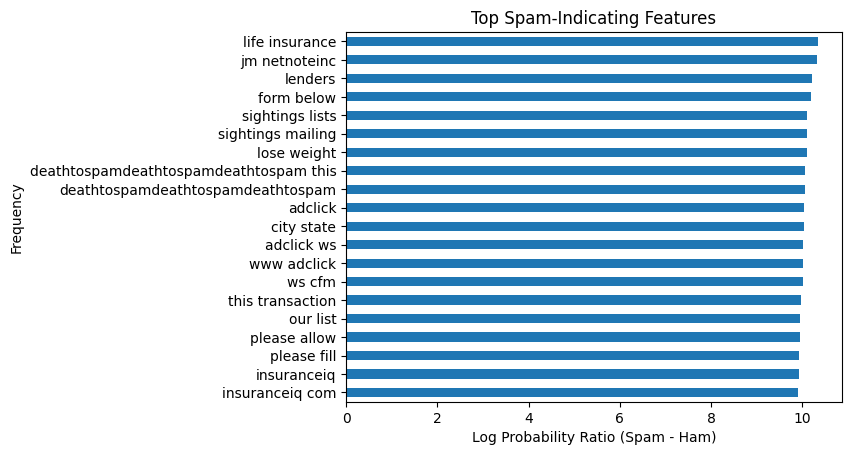

In [30]:
pd.DataFrame(top_spam_features,columns=['feature','score']).set_index("feature").plot(kind='barh',legend=False)
plt.title('Top Spam-Indicating Features')
plt.xlabel('Log Probability Ratio (Spam - Ham)')
plt.ylabel('Frequency')
plt.show()


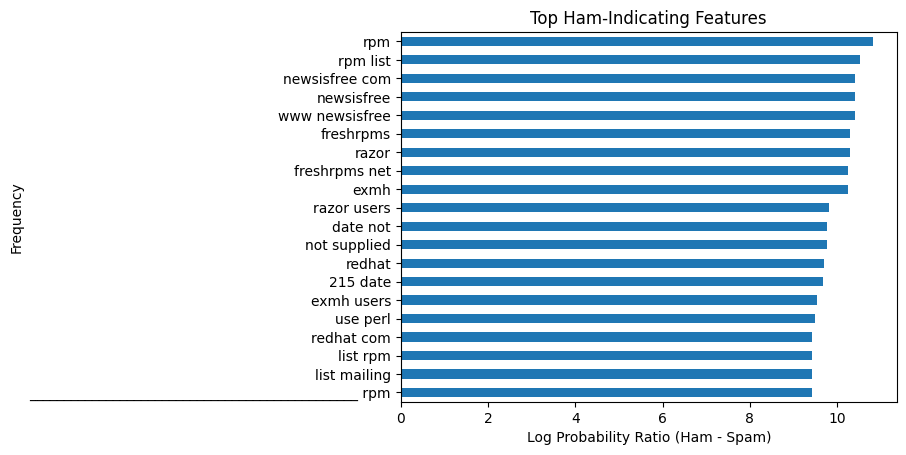

In [31]:
pd.DataFrame(top_ham_features,columns=['feature','score']).set_index("feature").plot(kind='barh',legend=False)
plt.title('Top Ham-Indicating Features')
plt.xlabel('Log Probability Ratio (Ham - Spam)')
plt.ylabel('Frequency')
plt.show()
